In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import anafibre as fib
from astropy import units as u
from IPython.display import display, HTML, Latex, Math

In [2]:
fibre = fib.StepIndexFibre(
    core_radius = 190*u.nm,     # core radius
    eps_core = 4.3,              # refractive index of core      
    eps_clad = 1.7,              # refractive index of cladding
) 

In [3]:
lam = 1310*u.nm    # wavelength
mode = fibre.HE(ell=1, n=1, wl=lam, a_plus=0, a_minus=1)
display(mode)

Mode,ℓ,m,λ [nm],V,ne,s1,s2,s3
HE11,1,1,IR1310.00,1.47,1.3760,0.00,0.00,-1.00


In [4]:
from anafibre.plotting import  animate_fields_xy
from IPython.display import display, HTML, Latex
from matplotlib.animation import PillowWriter
anim = animate_fields_xy(modes=mode, show=("E",),figsize=(5,5))
display(HTML(anim.to_jshtml()))

In [5]:
unt=u.W
precision=3
display(Math((mode.Power()*u.W).to(unt).to_string(unit=unt, format='latex',precision=precision)))

<IPython.core.display.Math object>

In [6]:
r = 1.5 * fibre.core_radius  # Radius in micrometers
Nr = 800  # Number of points in radial direction
rho = np.linspace(0, r, Nr) * u.m
Nphi = int(2 * np.pi * (Nr-1))
phi = np.linspace(0, 2 * np.pi, Nphi)
Rho, Phi = np.meshgrid(rho, phi)
We=mode.We(rho=Rho, phi=Phi, z=0)
Wm=mode.Wm(rho=Rho, phi=Phi, z=0)
W0= We + Wm
W1= We - Wm
W2=mode.W2(rho=Rho, phi=Phi, z=0)
W3=mode.W3(rho=Rho, phi=Phi, z=0)

In [7]:
# Plotting parameters
kwargs = dict(
    variant="dark", Rho=Rho, Phi=Phi,
    core_radius=fibre.core_radius*u.m,
    phase_cbar_style="edge",
    cbar_pad=-0.06,
    use_tex=False,   # set True if your system has LaTeX installed
    # vmax=7e20
)

kwargsE = {**kwargs, 'title': r"$W_e$", 'mag_label': r"$|W_e|$"}
kwargsM = {**kwargs, 'title': r"$W_m$", 'mag_label': r"$|W_m|$"}
kwargs0 = {**kwargs, 'title': r"$W_0$", 'mag_label': r"$|W_0|$"}
kwargs1 = {**kwargs, 'title': r"$W_1$", 'mag_label': r"$|W_1|$"}
kwargs2 = {**kwargs, 'title': r"$W_2$", 'mag_label': r"$|W_2|$"}
kwargs3 = {**kwargs, 'title': r"$W_3$", 'mag_label': r"$|W_3|$"}

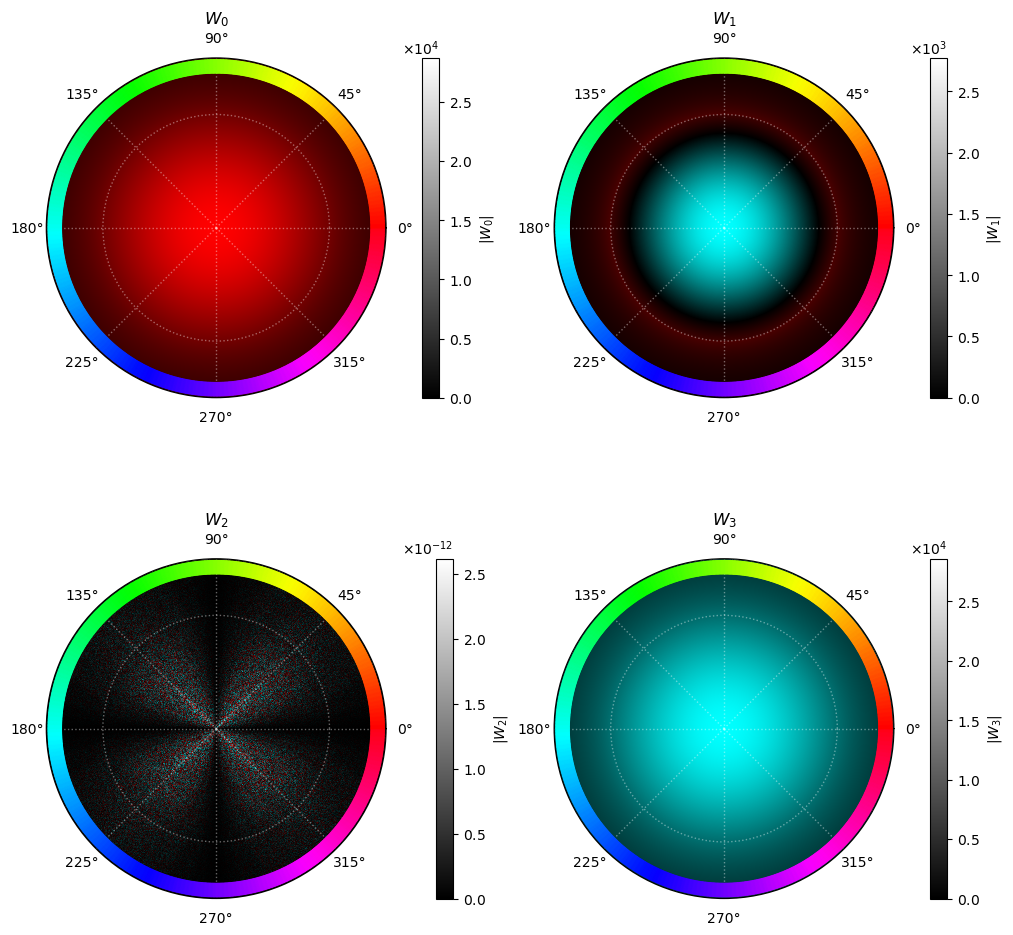

In [8]:
from anafibre.plotting import plot_complex_field_polar
fig, axs = plt.subplots(2, 2, subplot_kw=dict(projection='polar'), figsize=(10, 10), constrained_layout=True)
# plot_complex_field_polar(We, ax=axs[0, 0], **kwargsE)
# plot_complex_field_polar(Wm, ax=axs[0, 1], **kwargsM)
plot_complex_field_polar(W0, ax=axs[0, 0], **kwargs0)
plot_complex_field_polar(W1, ax=axs[0, 1], **kwargs1)
plot_complex_field_polar(W2, ax=axs[1, 0], **kwargs2)
plot_complex_field_polar(W3, ax=axs[1, 1], **kwargs3)
plt.show()